## Additional Analysis On Output

In [13]:
from collections import Counter
import itertools
import math
import random
from collections import Counter, defaultdict, OrderedDict
from itertools import combinations, islice
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy
from scipy.linalg import expm, eig, norm
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.patches as mpatches
import community as c  # You may only need one of these
import MDAnalysis as mda
from MDAnalysis.coordinates.XTC import XTCWriter
import mdtraj as md
import pickle

The following stored dictionaries come from running clustering_uplets.ipynb

In [14]:
%store -r kd_centrality_ordered
%store -r inv_map
%store -r dictionary_transitions_sorted


### Calculating Linear Motifs


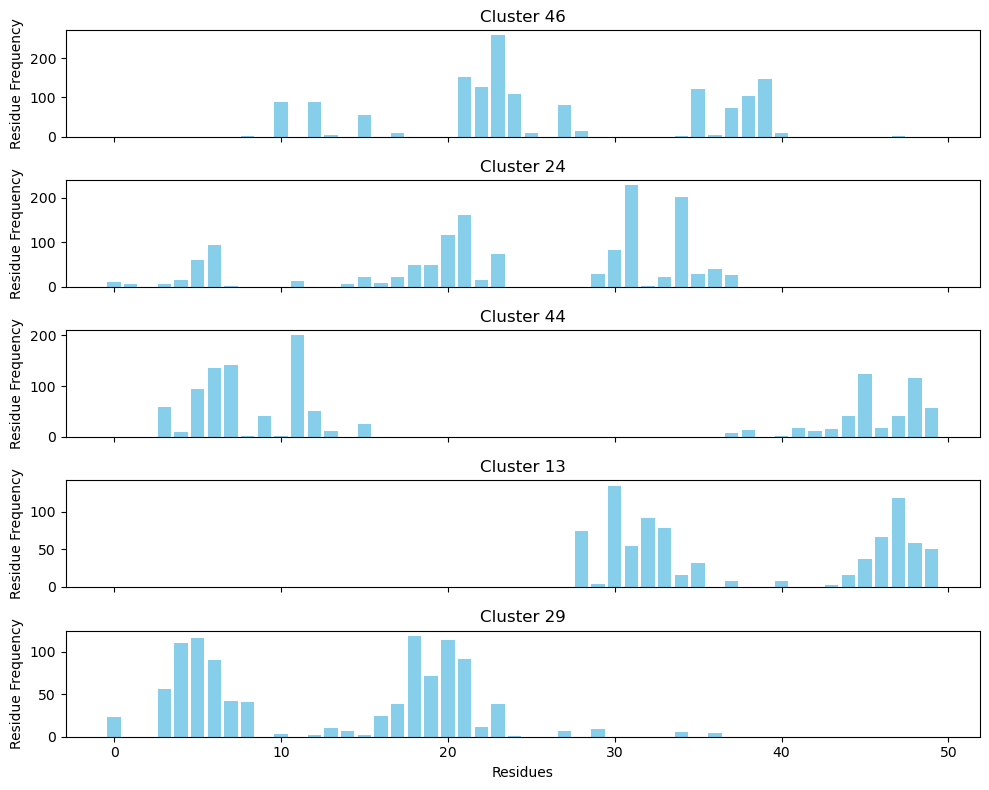

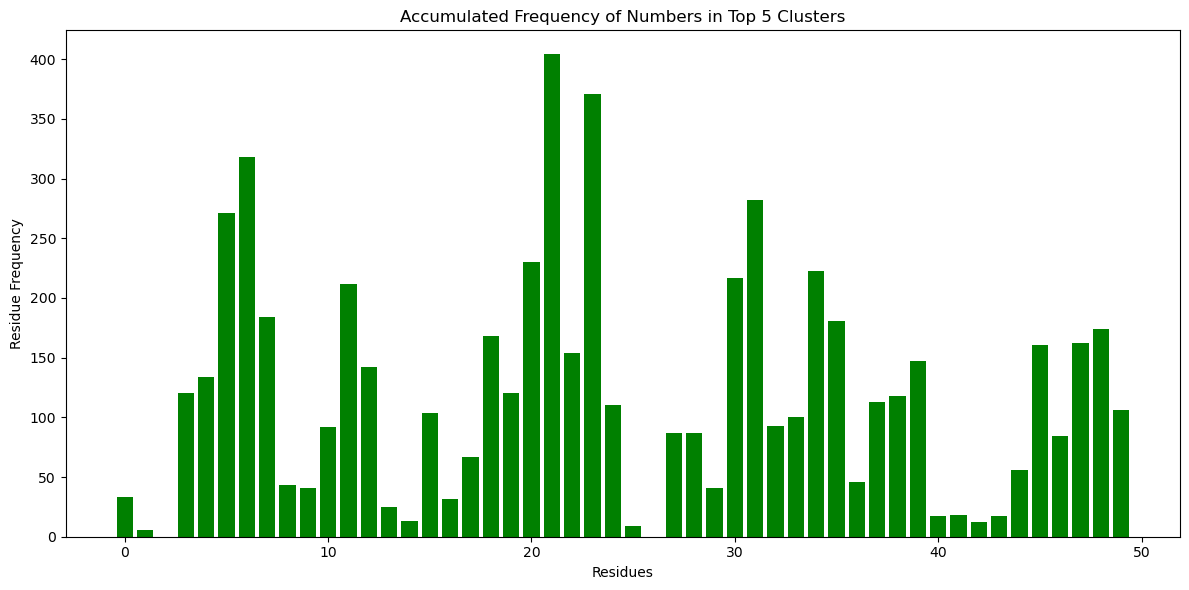

In [15]:
fig, axs = plt.subplots(5,1 , figsize=(10, 8), sharex=True)

all_cluster_elements=[]
axs = axs.ravel()  # Flatten the 2D array to 1D for easy indexing

for i, x in enumerate(list(kd_centrality_ordered.keys())[:5]):
    cluster = [elem for xs in inv_map[x] for elem in xs]
    frequency = Counter(cluster)
    all_cluster_elements.extend(cluster)

    x_vals = sorted(frequency.keys())
    y_vals = [frequency[num] for num in x_vals]

    axs[i].bar(x_vals, y_vals, color='skyblue')
    axs[i].set_ylabel('Residue Frequency')
    axs[i].set_title(f'Cluster {x}')

plt.xlabel('Residues')
plt.tight_layout()
plt.show()


frequency_all_cluster = Counter(all_cluster_elements)
x_vals_all = sorted(frequency_all_cluster.keys())
y_vals_all = [frequency_all_cluster[num] for num in x_vals_all]

# Plotting
plt.figure(figsize=(12, 6))
plt.bar(x_vals_all, y_vals_all, color='green')
plt.xlabel('Residues')
plt.ylabel('Residue Frequency')
plt.title('Accumulated Frequency of Numbers in Top 5 Clusters')
plt.tight_layout()
plt.show()

## Gliding versus Hopping Mechanism

Distribution of transition frequencies between quintuplets, categorized by their pairwise similarity scores

In [16]:

def jaccard(list1, list2):
    intersection = len(list(set(list1).intersection(list2)))
    union = (len(list1) + len(list2)) - intersection
    similarity=float(intersection) / union
    distance=1-similarity
    return similarity,distance

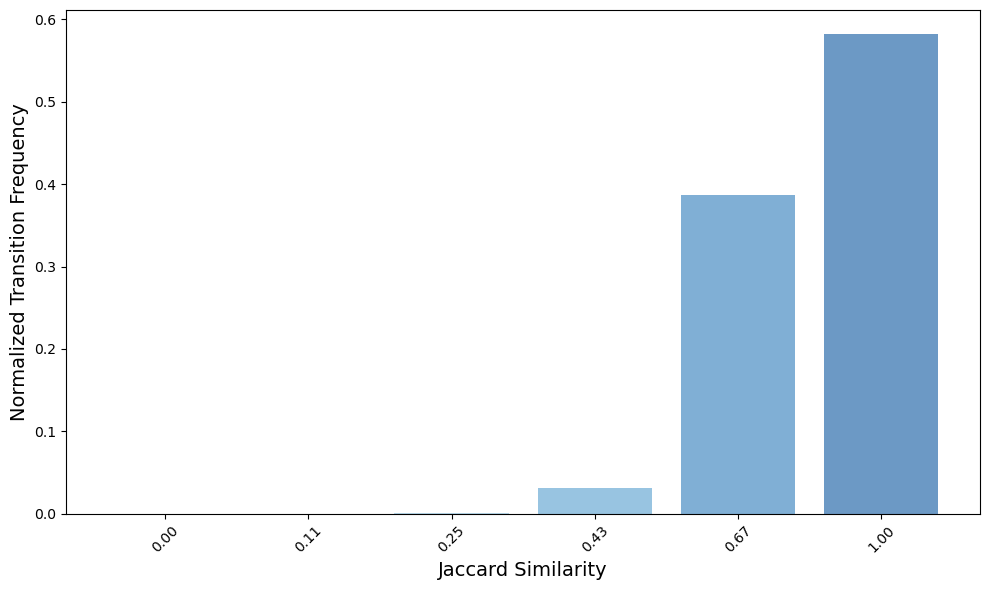

In [17]:

jaccard_scores_more_less_plot_1 = []

for keys, values in dictionary_transitions_sorted.items():
    similarity=(jaccard(keys[0],keys[1]))[0]
    jaccard_scores_more_less_plot_1.append([values,similarity])

jaccard_scores_more_less_sorted_plot_1 = sorted(jaccard_scores_more_less_plot_1, key=lambda x: x[1], reverse=True)
total = sum([x[0] for x in jaccard_scores_more_less_plot_1])

# Normalize
normalized_data = [[x[0] / total, x[1]] for x in jaccard_scores_more_less_plot_1]

aggregated = defaultdict(float)
for value, key in normalized_data:
    aggregated[key] += value

aggregated_dict = dict(sorted(aggregated.items()))
x = list(aggregated_dict.keys())
y = list(aggregated_dict.values())

colors = sns.color_palette("Blues", len(x))
plt.figure(figsize=(10, 6))
plt.bar(range(len(x)), y, color=colors, alpha=0.6, label="Normalized Frequency")

plt.xticks(ticks=range(len(x)), labels=[f"{val:.2f}" for val in x], rotation=45)
plt.xlabel("Jaccard Similarity", fontsize=14)
plt.ylabel("Normalized Transition Frequency", fontsize=14)
plt.tight_layout()
#plt.savefig(f'/Users/adelielouet/Documents/science/dd_proj/msm_full_model_paper/figures/gliding_v_hopping_freq_distr.png', dpi=300)
plt.show()

/var/folders/y3/sm2gn5053mz_rtfqrj0r8mz40000gn/T/ipykernel_53882/569803522.py:68: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[trans for sim, trans in y_normalized_jac], y=[f"{k[0]} --> {k[1]}" for k in clean_data], palette=colors)


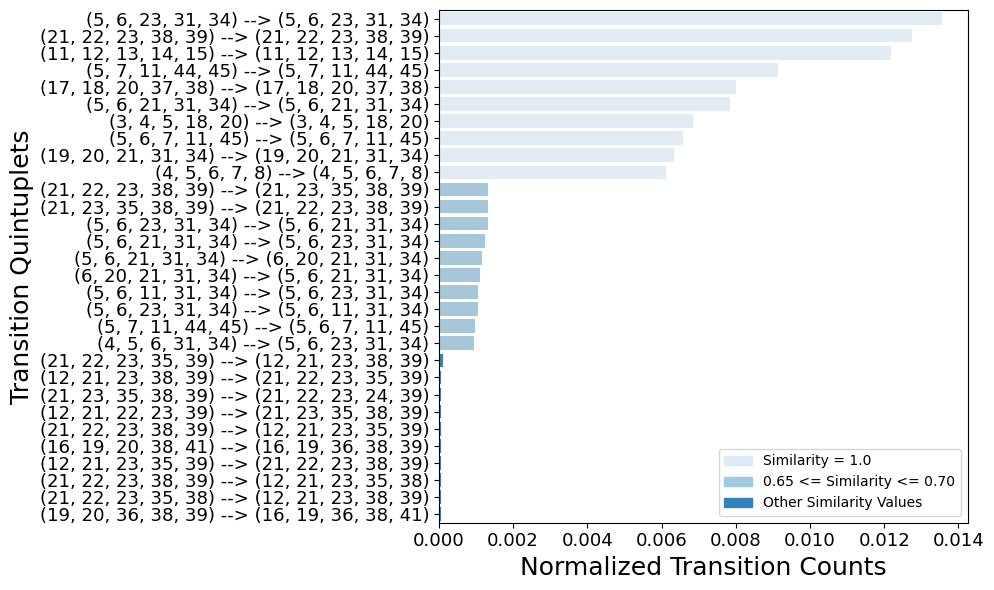

In [19]:

#Plot part b
jaccard_scores_more_less = {}
count_more_1 = 0
count_less_70 = 0
count_less_60=0

for keys, values in dictionary_transitions_sorted.items():
    if count_more_1 >= 10 and count_less_70 >= 10 and count_less_60>= 10:
        break  

    j_similarity, j_distancejaccard = jaccard(list(keys[0]), list(keys[1]))
    k = tuple(keys)

    if count_more_1 < 10 and j_similarity == 1.0:
        jaccard_scores_more_less[k] = j_similarity,values
        count_more_1 += 1

    if count_less_70 < 10 and j_similarity <= 0.70:
        jaccard_scores_more_less[k] = j_similarity,values
        count_less_70 += 1


    elif count_less_60 < 10 and j_similarity <= 0.60:
        jaccard_scores_more_less[k] = j_similarity,values
        count_less_60 += 1

x_jac = list(jaccard_scores_more_less.keys())
y_jac= list(jaccard_scores_more_less.values())
#y_normalized_jac = y_jac

y_sum=sum(dictionary_transitions_sorted.values())
y_normalized_jac = [(sim, trans / y_sum) for sim, trans in y_jac]

colors = []
for sim, _ in y_normalized_jac:
    if sim == 1.0:
        colors.append("#deebf7")  # Blue for perfect similarity
    elif 0.60 <= sim <= 0.70:
        colors.append("#9ecae1")  # Lighter blue for medium similarity
    elif 0.0 <= sim <= 0.60:
        colors.append("#3182bd")  # Lightest blue for other values


unique_states = set()
for k in x_jac:
    unique_states.add(k[0])
    unique_states.add(k[1])

#state_to_num = {state: f"State {i}" for i, state in enumerate(sorted(unique_states), 1)}
state_to_num = {state: f"{i}" for i, state in enumerate(sorted(unique_states), 1)}

# Replace transitions with their numbered labels
#y_labels = [f"{state_to_num[k[0]]} -> {state_to_num[k[1]]}" for k in x_jac]

#y_labels = [f"{state_to_num[k[0]]} → {state_to_num[k[1]]}" for k in x_jac]

#sns.barplot(x=[trans for sim, trans in y_normalized_jac], y=y_labels, palette=colors)

clean_data = [
    (
        tuple(int(x) for x in pair[0]),
        tuple(int(x) for x in pair[1])
    )
    for pair in x_jac
]

plt.figure(figsize=(10, 6))
sns.barplot(x=[trans for sim, trans in y_normalized_jac], y=[f"{k[0]} --> {k[1]}" for k in clean_data], palette=colors)
# sns.barplot(x=[trans for sim, trans in y_normalized_jac], y=y_labels, palette=colors)

blue_patch_1 = mpatches.Patch(color="#deebf7", label="Similarity = 1.0")
blue_patch_2 = mpatches.Patch(color="#9ecae1", label="0.65 <= Similarity <= 0.70")
blue_patch_3 = mpatches.Patch(color="#3182bd", label="Other Similarity Values")

plt.legend(handles=[blue_patch_1, blue_patch_2, blue_patch_3], loc="lower right")

plt.xlabel('Normalized Transition Counts',fontsize=18)
plt.ylabel('Transition Quintuplets',fontsize=18)
#plt.title(f'Transitions for {protein_name} Quintuplets', fontsize=13, fontweight="bold")

plt.xticks(fontsize=13)
plt.yticks(fontsize=13)

plt.tight_layout()
#plt.savefig(f'/Users/adelielouet/Documents/science/dd_proj/msm_full_model_paper/figures/gliding_v_hopping_top_trans.png', dpi=300)

plt.show()



/var/folders/y3/sm2gn5053mz_rtfqrj0r8mz40000gn/T/ipykernel_53882/1664312669.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=[trans for sim, trans in y_normalized_jac], x=transition_labels, palette=colors)


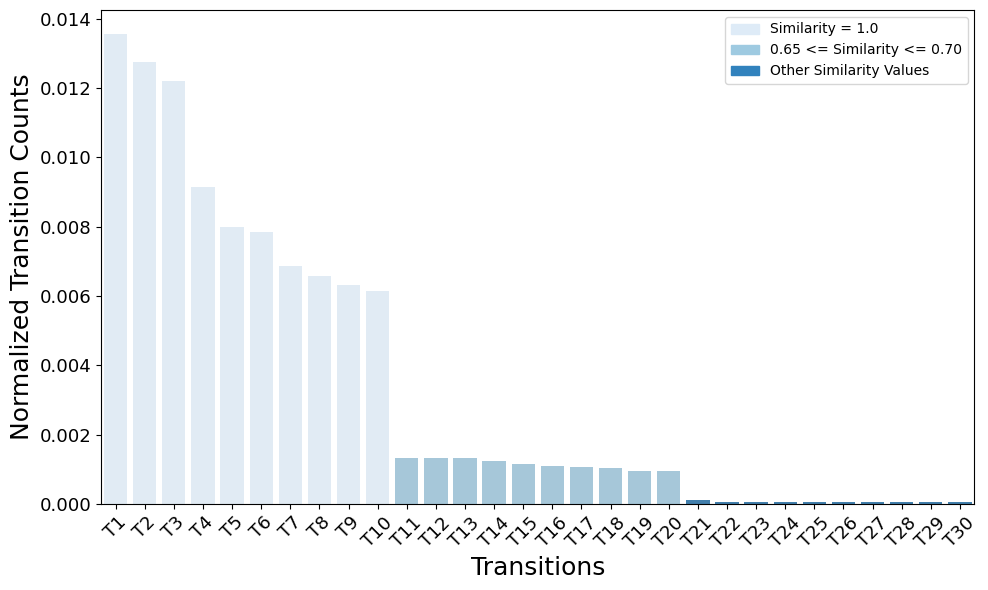

In [20]:

##### Different visual represnation

transition_labels = [f"T{i+1}" for i in range(len(x_jac))]

# Create a mapping from T-labels to original transitions
transition_map = {
    f"T{i+1}": (state_to_num[k[0]], state_to_num[k[1]]) for i, k in enumerate(x_jac)
}

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(y=[trans for sim, trans in y_normalized_jac], x=transition_labels, palette=colors)

blue_patch_1 = mpatches.Patch(color="#deebf7", label="Similarity = 1.0")
blue_patch_2 = mpatches.Patch(color="#9ecae1", label="0.65 <= Similarity <= 0.70")
blue_patch_3 = mpatches.Patch(color="#3182bd", label="Other Similarity Values")
plt.legend(handles=[blue_patch_1, blue_patch_2, blue_patch_3])

plt.ylabel('Normalized Transition Counts', fontsize=18)
plt.xlabel('Transitions', fontsize=18)
plt.yticks(fontsize=13)
plt.xticks(fontsize=13,rotation=45)
plt.tight_layout()
#plt.savefig(f'/Users/adelielouet/Documents/science/dd_proj/msm_full_model_paper/figures/gliding_v_hopping_top_trans_rep_as_T.png', dpi=300)
plt.show()
